In [ ]:
#code 1
from google.colab import files

uploaded = files.upload()

In [ ]:
#code 17
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
48,vhigh,vhigh,3,more,med,low
468,high,vhigh,3,4,small,low
155,vhigh,high,3,more,small,high
1721,low,low,5more,more,small,high
1208,med,low,2,more,small,high


X_train: Ini adalah variabel yang biasanya digunakan untuk menyimpan subset data yang digunakan untuk pelatihan (training) model machine learning. X_train biasanya merupakan DataFrame pandas yang berisi fitur (features) yang akan digunakan untuk melatih model.

head(): Ini adalah metode pandas yang digunakan untuk menampilkan beberapa baris pertama dari DataFrame. Secara default, head() akan menampilkan lima baris pertama.

In [ ]:
#code 18
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']):
Baris ini membuat objek OrdinalEncoder dari library category_encoders.
OrdinalEncoder digunakan untuk mengubah variabel kategori menjadi angka ordinal (numerik).
cols adalah parameter yang menentukan daftar nama kolom yang akan diencode. Dalam kasus ini, kolom ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'] akan diencode.

X_train = encoder.fit_transform(X_train):
fit_transform adalah metode yang melakukan dua hal: menyesuaikan encoder dengan data (fit) dan kemudian mengubah data (transform).
Dengan kata lain, encoder akan mempelajari bagaimana mengubah kategori dalam kolom yang ditentukan menjadi angka ordinal berdasarkan data di X_train dan langsung menerapkan transformasi ini pada X_train.
Hasilnya adalah X_train yang telah diubah, di mana nilai-nilai kategori telah digantikan dengan nilai numerik ordinal.

X_test = encoder.transform(X_test):
transform adalah metode yang hanya mengubah data berdasarkan penyesuaian yang telah dipelajari oleh encoder dari X_train.
Dalam hal ini, X_test akan diubah dengan aturan yang sama yang diterapkan pada X_train.
Hasilnya adalah X_test yang juga telah diubah, dengan nilai-nilai kategori yang digantikan oleh nilai numerik ordinal.

Secara keseluruhan, fungsi dari kode ini adalah:
Mengubah variabel kategori dalam kolom ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'] menjadi nilai numerik ordinal dalam dataset X_train dan X_test.
Encoder pertama kali "belajar" dari X_train (dengan fit_transform) dan kemudian menerapkan transformasi yang sama ke X_test (dengan transform).
Ini adalah langkah penting dalam praproses data sebelum digunakan dalam algoritma machine learning yang membutuhkan input numerik.

X_train: Ini adalah variabel yang biasanya digunakan untuk menyimpan subset data yang digunakan untuk pelatihan (training) model machine learning. X_train biasanya merupakan DataFrame pandas yang berisi fitur (features) yang akan digunakan untuk melatih model.

head(): Ini adalah metode pandas yang digunakan untuk menampilkan beberapa baris pertama dari DataFrame. Secara default, head() akan menampilkan lima baris pertama.

In [ ]:
#code 20
X_test.head()

,buying,maint,doors,persons,lug_boot,safety
599,2,2,4,3,1,2
1201,4,3,3,2,1,3
628,2,2,2,3,3,3
1498,3,2,2,2,1,3
1263,4,3,4,1,1,1


X_test: Ini adalah variabel yang biasanya menyimpan subset data yang digunakan untuk menguji (testing) model machine learning. X_test biasanya merupakan DataFrame pandas yang berisi fitur-fitur yang akan digunakan untuk menguji model yang sudah dilatih.

head(): Ini adalah metode pandas yang digunakan untuk menampilkan beberapa baris pertama dari DataFrame. Secara default, head() akan menampilkan lima baris pertama. Anda bisa menentukan jumlah baris yang ingin ditampilkan dengan memberikan argumen ke head(), misalnya head(10) akan menampilkan sepuluh baris pertama.

In [ ]:
# code 21
from sklearn.ensemble import RandomForestClassifier

rfc_10 = RandomForestClassifier(n_estimators=10, random_state=0)

rfc_10.fit(X_train, y_train)

y_pred_10 = rfc_10.predict(X_test)

from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred_10)))

NameError: name 'X_train' is not defined

In [ ]:
# code 22
from sklearn.ensemble import RandomForestClassifier

rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)

rfc_100.fit(X_train, y_train)

y_pred_100 = rfc_100.predict(X_test)

from sklearn.metrics import accuracy_score

print('Model accuracy score with 100 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred_100)))

Model accuracy score with 100 decision-trees : 0.9457


In [ ]:
#code 22.2
  from sklearn.ensemble import RandomForestClassifier
  clf = RandomForestClassifier(random_state=0)

  clf.fit(X_train, y_train)

  y_pred = clf.predict(X_test)

  print('Model accuracy score with doors variable not  removed : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with doors variable not  removed : 0.9457


In [ ]:
#code 23
clf = RandomForestClassifier(n_estimators=100, random_state=0)

clf.fit(X_train, y_train)

print(clf.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}


In [ ]:
#code 24
feature_scores = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores

safety      0.295319
persons     0.233856
buying      0.151734
maint       0.146653
lug_boot    0.100048
doors       0.072389
dtype: float64

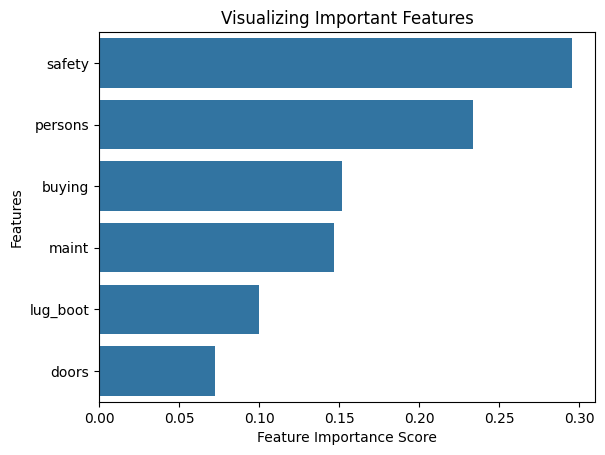

In [ ]:
#code 25
sns.barplot(x=feature_scores, y=feature_scores.index)

plt.xlabel('Feature Importance Score')

plt.ylabel('Features')

plt.title("Visualizing Important Features")

plt.show()

In [ ]:
#code 26
X = df.drop(['class', 'doors'], axis=1)

y = df['class']


In [ ]:
#code 27
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [ ]:
#code 28
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'persons', 'lug_boot', 'safety'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

encoder = ce.OrdinalEncoder(cols=['buying', 'maint', '', 'persons', 'lug_boot', 'safety']):
Baris ini membuat objek OrdinalEncoder dari library category_encoders.
OrdinalEncoder digunakan untuk mengubah variabel kategori menjadi angka ordinal (numerik).
cols adalah parameter yang menentukan daftar nama kolom yang akan diencode. Dalam kasus ini, kolom ['buying', 'maint', '', 'persons', 'lug_boot', 'safety'] akan diencode.

X_train = encoder.fit_transform(X_train):
fit_transform adalah metode yang melakukan dua hal: menyesuaikan encoder dengan data (fit) dan kemudian mengubah data (transform).
Dengan kata lain, encoder akan mempelajari bagaimana mengubah kategori dalam kolom yang ditentukan menjadi angka ordinal berdasarkan data di X_train dan langsung menerapkan transformasi ini pada X_train.
Hasilnya adalah X_train yang telah diubah, di mana nilai-nilai kategori telah digantikan dengan nilai numerik ordinal.

X_test = encoder.transform(X_test):
transform adalah metode yang hanya mengubah data berdasarkan penyesuaian yang telah dipelajari oleh encoder dari X_train.
Dalam hal ini, X_test akan diubah dengan aturan yang sama yang diterapkan pada X_train.
Hasilnya adalah X_test yang juga telah diubah, dengan nilai-nilai kategori yang digantikan oleh nilai numerik ordinal.

Secara keseluruhan, fungsi dari kode ini adalah:
Mengubah variabel kategori dalam kolom ['buying', 'maint', '', 'persons', 'lug_boot', 'safety'] menjadi nilai numerik ordinal dalam dataset X_train dan X_test.
Encoder pertama kali "belajar" dari X_train (dengan fit_transform) dan kemudian menerapkan transformasi yang sama ke X_test (dengan transform).
Ini adalah langkah penting dalam praproses data sebelum digunakan dalam algoritma machine learning yang membutuhkan input numerik.

In [ ]:
#code 29
clf = RandomForestClassifier(random_state=0)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Model accuracy score with doors variable removed : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with doors variable removed : 0.9264


clf = RandomForestClassifier(random_state=0)
Membuat instance dari RandomForestClassifier dengan random_state=0. Parameter random_state memastikan bahwa hasil yang diperoleh dapat direproduksi (konsisten setiap kali kode dijalankan dengan dataset yang sama).

clf.fit(X_train, y_train)
Melatih model Random Forest menggunakan data pelatihan X_train (fitur-fitur) dan y_train (label).

y_pred = clf.predict(X_test)
Menggunakan model yang telah dilatih untuk memprediksi label pada data uji X_test. Hasil prediksi disimpan dalam variabel y_pred.

print('Model accuracy score with doors variable removed : {0:0.4f}'.format(accuracy_score(y_test, y_pred)))
Menghitung akurasi prediksi dengan membandingkan label sebenarnya y_test dengan label prediksi y_pred menggunakan fungsi accuracy_score.
Mencetak skor akurasi dengan format yang ditentukan.
Format {0:0.4f} dalam fungsi print digunakan untuk mengatur tampilan angka dalam string. Ini adalah bagian dari metode str.format di Python, yang memungkinkan format string yang lebih fleksibel. Mari kita uraikan maknanya:

In [ ]:
#code 30
X = df.drop(['class', 'lug_boot'], axis=1)

y = df['class']


In [ ]:
#code 31
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [ ]:
#code 32
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'safety'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', '', 'safety']):
Baris ini membuat objek OrdinalEncoder dari library category_encoders.
OrdinalEncoder digunakan untuk mengubah variabel kategori menjadi angka ordinal (numerik).
cols adalah parameter yang menentukan daftar nama kolom yang akan diencode. Dalam kasus ini, kolom ['buying', 'maint', 'doors', 'persons', '', 'safety'] akan diencode.

X_train = encoder.fit_transform(X_train):
fit_transform adalah metode yang melakukan dua hal: menyesuaikan encoder dengan data (fit) dan kemudian mengubah data (transform).
Dengan kata lain, encoder akan mempelajari bagaimana mengubah kategori dalam kolom yang ditentukan menjadi angka ordinal berdasarkan data di X_train dan langsung menerapkan transformasi ini pada X_train.
Hasilnya adalah X_train yang telah diubah, di mana nilai-nilai kategori telah digantikan dengan nilai numerik ordinal.

X_test = encoder.transform(X_test):
transform adalah metode yang hanya mengubah data berdasarkan penyesuaian yang telah dipelajari oleh encoder dari X_train.
Dalam hal ini, X_test akan diubah dengan aturan yang sama yang diterapkan pada X_train.
Hasilnya adalah X_test yang juga telah diubah, dengan nilai-nilai kategori yang digantikan oleh nilai numerik ordinal.

Secara keseluruhan, fungsi dari kode ini adalah:
Mengubah variabel kategori dalam kolom ['buying', 'maint', 'doors', 'persons', '', 'safety'] menjadi nilai numerik ordinal dalam dataset X_train dan X_test.
Encoder pertama kali "belajar" dari X_train (dengan fit_transform) dan kemudian menerapkan transformasi yang sama ke X_test (dengan transform).
Ini adalah langkah penting dalam praproses data sebelum digunakan dalam algoritma machine learning yang membutuhkan input numerik.

In [ ]:
#code 33
clf = RandomForestClassifier(random_state=0)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Model accuracy score with lug_boot variable removed : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with lug_boot variable removed : 0.8371


clf = RandomForestClassifier(random_state=0)
Membuat instance dari RandomForestClassifier dengan random_state=0. Parameter random_state memastikan bahwa hasil yang diperoleh dapat direproduksi (konsisten setiap kali kode dijalankan dengan dataset yang sama).

clf.fit(X_train, y_train)
Melatih model Random Forest menggunakan data pelatihan X_train (fitur-fitur) dan y_train (label).

y_pred = clf.predict(X_test)
Menggunakan model yang telah dilatih untuk memprediksi label pada data uji X_test. Hasil prediksi disimpan dalam variabel y_pred.

print('Model accuracy score with doors variable removed : {0:0.4f}'.format(accuracy_score(y_test, y_pred)))
Menghitung akurasi prediksi dengan membandingkan label sebenarnya y_test dengan label prediksi y_pred menggunakan fungsi accuracy_score.
Mencetak skor akurasi dengan format yang ditentukan.
Format {0:0.4f} dalam fungsi print digunakan untuk mengatur tampilan angka dalam string. Ini adalah bagian dari metode str.format di Python, yang memungkinkan format string yang lebih fleksibel. Mari kita uraikan maknanya:

In [ ]:
Se 1#code 34
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_100))

              precision    recall  f1-score   support

         acc       0.90      0.88      0.89       129
        good       0.61      0.85      0.71        20
       unacc       0.99      0.98      0.98       397
       vgood       0.87      0.80      0.83        25

    accuracy                           0.95       571
   macro avg       0.84      0.88      0.85       571
weighted avg       0.95      0.95      0.95       571



classification mengambil data  y test dan y pred dari model random forest mengunakan 100 decision tree

In [ ]:
# code 35
y_test.value_counts()

class
unacc    397
acc      129
vgood     25
good      20
Name: count, dtype: int64

In [ ]:
# code 36
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

cm = confusion_matrix(y_test, y_pred_100)

label_encoder = LabelEncoder()
label_encoder.fit(y_test)
class_order = label_encoder.classes_

print("Confusion Matrix:")
print(cm)
print("Class Order:")
print(class_order)


Confusion Matrix:
[[114   9   4   2]
 [  2  17   0   1]
 [  8   0 389   0]
 [  3   2   0  20]]
Class Order:
['acc' 'good' 'unacc' 'vgood']


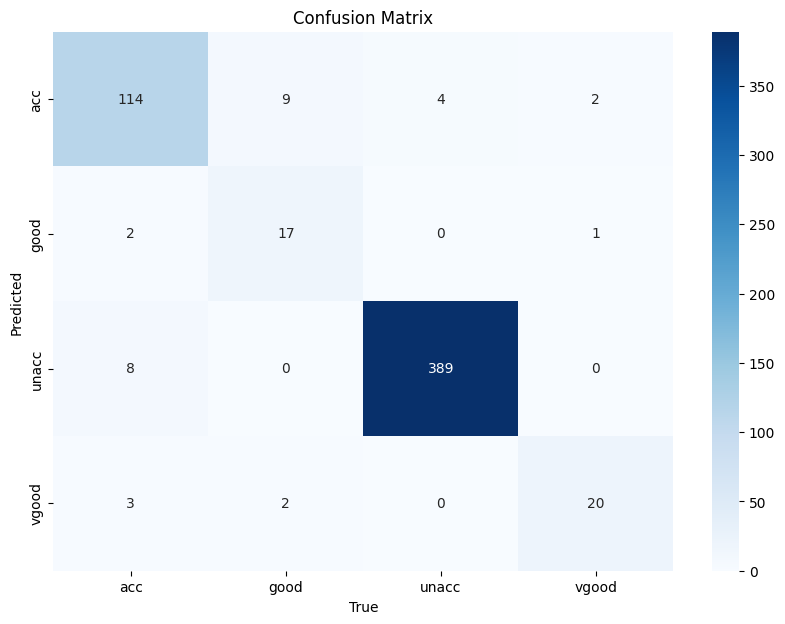

In [ ]:
# code 37
from sklearn.metrics import confusion_matrix

class_names = ['acc', 'good', 'unacc', 'vgood']

cm = confusion_matrix(y_test, y_pred_100)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred_10)
print(f'Akurasi: {accuracy:.2f}')

KESIMPULAN

1. Dalam proyek ini, Kami membangun Random Forest Classifier untuk memprediksi keamanan mobil. kami membuat dua model, satu dengan 10 pohon keputusan dan satu lagi dengan 100 pohon keputusan.
2. Nilai akurasi model dengan 10 pohon keputusan adalah 0.9247, namun nilai akurasi model dengan 100 pohon keputusan adalah 0.9457. Jadi, seperti yang diharapkan, akurasi meningkat dengan jumlah pohon keputusan dalam model.
3. Kami telah menggunakan model Random Forest untuk menemukan fitur-fitur yang penting saja, membangun model dengan menggunakan fitur-fitur tersebut dan melihat pengaruhnya terhadap akurasi. Fitur yang paling penting adalah keamanan dan fitur yang paling tidak penting adalah pintu.
4. Kami telah menghapus variabel pintu dari model, membangunnya kembali dan memeriksa akurasinya. Akurasi model dengan variabel pintu yang telah dihapus adalah 0.9264. Akurasi model dengan semua variabel yang diperhitungkan adalah 0.9457. Jadi, kita dapat melihat bahwa akurasi model telah berkurang dengan mengeluarkan variabel pintu dari model  walaupun berkurang tidak terlalu jauh.
5. fitur kedua yang paling tidak penting adalah lug_boot. Jika Kami menghapusnya dari model dan membangun ulang model, maka akurasinya menjadi 0.8371. Ini adalah penurunan yang signifikan dalam akurasi. Jadi, Kami tidak akan menghapusnya dari model.
6. Confusion Matrix dan laporan klasifikasi adalah alat lain untuk memvisualisasikan kinerja model. Mereka menghasilkan kinerja yang baik.